# Experiment Framedrop

**Date**: 11 July 2026

**Issue**: The recordings do not have consisten framerate. Upon inspection, we found that the storage (SSD) is utilized at 100% during the recording.

Our first inspection is changing the recording configuration to produce less bandwidth (eg. lower resolution, lower framerate).
The result is the SSD utilization never hit 100% again.
This furthur indicate that the problem is at bandwidth of the storage.

The second inspection is we split the recording to 2 SSDs (one internal, another external).
In this configuration, the utilization of both SSD never hit 100%.
This futhur indicate that we can scale that recording by adding more storage.

Thus, the main objective of this experiment is will inconsistent framerate be fixed by spliting the recording to multiple SSDs

**Objective**: Investigate and proof that the inconsistent framerate is the result of insufficient IO bandwidth.


**Hypothesis**: By spliting the recording to each SSDs, we will have enough bandwidth to accomodate the recordings. Thus, there should be no framedrop.

**Experiment**: There will be 4 configurations.

| Configuration | Realsense | Mirrorless |
|---------------|-----------|------------|
| A             | internal  | internal   |
| B             | external  | external   |
| C             | internal  | external   |
| D             | external  | internal   |

In expect that configuration A and B will exhibit framedrop while C and D will not.

In [7]:
from pathlib import Path
import os
DATA_PATH = Path(os.getcwd()).parent / "data"
RAW_PATH = DATA_PATH / "experiment-framedrop"

In [8]:
bag_files = sorted(list(RAW_PATH.glob("*.bag")))
bag_files

[PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/A-m.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/A-r.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/B-m.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/B-r.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/C-m.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/C-r.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/D-m.bag'),
 PosixPath('/mnt/pool-1/projects/ubuntu/AIT-brainlab/sign-language/data/experiment-framedrop/D-r.bag')]

In [9]:
from datetime import datetime
def process(pipeline, history, log_file_name):
    try:
        log_file = open(log_file_name, "w")
        fps = pipeline.get_active_profile().get_stream(rs.stream.color).as_video_stream_profile().fps()
        frame_in_second = 0
        current_second = 0
        while True:
            # Wait for the next set of frames
            frames = pipeline.wait_for_frames()

            # Retrieve specific streams
            depth_frame = frames.get_depth_frame()
            color_frame = frames.get_color_frame()
            
            # Retrieve IMU frames (if they were recorded)
            accel_frame = frames.first_or_default(rs.stream.accel)
            gyro_frame = frames.first_or_default(rs.stream.gyro)

            frame_tz = frames.get_timestamp()
            frame_time = datetime.fromtimestamp(frame_tz / 1000.0)
            frame_number = frames.get_frame_number()
            second = frame_time.second
            if second != current_second:
                history.append(frame_in_second)
                current_second = second
                frame_in_second = 0
            else:
                frame_in_second += 1
            log_file.write(f"FPS: {fps}, Frame Rate: {frame_in_second:03d}, Frame Number: {frame_number}, Timestamp: {frame_tz}, Time: {frame_time}\n")
            # Process Color Frame
            if color_frame:
                color_image = np.asanyarray(color_frame.get_data())
                color_image_bgr = cv2.cvtColor(color_image, cv2.COLOR_RGB2BGR)
                cv2.imshow("Color Stream", color_image_bgr)

            # Process Depth Frame
            if depth_frame:
                # print(frames.get_frame_metadata(depth_frame))
                depth_image = np.asanyarray(depth_frame.get_data())
                # Normalize depth to 8-bit for visualization
                depth_image_8bit = cv2.convertScaleAbs(depth_image, alpha=0.03)
                depth_colormap = cv2.applyColorMap(depth_image_8bit, cv2.COLORMAP_JET)
                cv2.imshow("Depth Stream", depth_colormap)

            # Process IMU Data
            if accel_frame:
                accel_data = accel_frame.as_motion_frame().get_motion_data()
                print(f"Accel: x={accel_data.x:.2f}, y={accel_data.y:.2f}, z={accel_data.z:.2f}")

            if gyro_frame:
                gyro_data = gyro_frame.as_motion_frame().get_motion_data()
                print(f"Gyro: x={gyro_data.x:.2f}, y={gyro_data.y:.2f}, z={gyro_data.z:.2f}")

            # Exit on pressing 'q'
            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                break

    finally:
        pipeline.stop()
        cv2.destroyAllWindows()
        log_file.close()

In [12]:
import pyrealsense2 as rs
import numpy as np
import cv2
bag_names = []
histories = []
for bag_file in bag_files:
    bag_names.append(bag_file.stem)
    # Configure playback from bag file
    pipeline = rs.pipeline()
    config = rs.config()
    config.enable_device_from_file(str(bag_file), repeat_playback=False)

    profile = pipeline.start(config)

    # Set the real-time flag to false for synchronous playback and frame grabbing
    device = profile.get_device()
    playback = device.as_playback()
    # Real-Time Playback: The playback.set_real_time(False) line is critical. 
    # It forces the pipeline to step through the frames as fast as your code allows, 
    # rather than matching the real-world timestamp rate of the hardware recording.
    playback.set_real_time(False) 
    history = []
    try:
        process(pipeline, history, bag_file.stem + "_frame_log.txt")
    except Exception as e:
        print(f"Error processing {bag_file.stem}: {e}")
    finally:
        with(open(bag_file.stem + "_frame_log.txt", "a") as log_file):
            log_file.write("\nFrame Rate History (Frames per Second):\n")
            log_file.write(f"{history}")
        histories.append(history)


Error processing A-m: Frame didn't arrive within 5000
Error processing A-r: Frame didn't arrive within 5000
Error processing B-m: Frame didn't arrive within 5000
Error processing B-r: Frame didn't arrive within 5000
Error processing C-m: Frame didn't arrive within 5000
Error processing C-r: Frame didn't arrive within 5000
Error processing D-m: Frame didn't arrive within 5000
Error processing D-r: Frame didn't arrive within 5000


Bag File: A-m
Frame Rate History: [0, 47, 93, 93, 95, 93, 93, 93, 95]
Bag File: A-r
Frame Rate History: [0, 14, 29, 29, 29, 29, 29, 29, 28]
Bag File: B-m
Frame Rate History: [0, 69, 68, 68, 69, 68, 69, 68, 70, 69, 68, 66]
Bag File: B-r
Frame Rate History: [0, 23, 29, 29, 29, 28, 29, 29, 29, 29, 29, 29]
Bag File: C-m
Frame Rate History: [0, 46, 68, 68, 67, 68, 67, 67, 67]
Bag File: C-r
Frame Rate History: [0, 25, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29]
Bag File: D-m
Frame Rate History: [0, 28, 89, 91, 91, 92, 92, 92, 92, 93, 93, 92, 92, 94]
Bag File: D-r
Frame Rate History: [0, 24, 29, 29, 29, 29, 29, 29, 29, 29, 29]


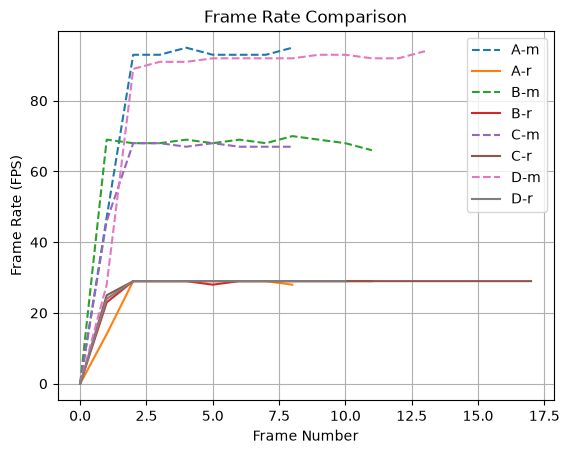

In [19]:

import matplotlib.pyplot as plt
for bag_name, history in zip(bag_names, histories):
    print(f"Bag File: {bag_name}")
    print(f"Frame Rate History: {history}")
    line_style = '-' if 'r' in bag_name else '--'
    plt.plot(history, label=bag_name, linestyle=line_style)
plt.xlabel("Frame Number")
plt.ylabel("Frame Rate (FPS)")
plt.title("Frame Rate Comparison")
plt.grid()
plt.legend()
plt.show()

In [ ]:
x